# Pilot: the 2020 Labor Day Fires (Holiday Farm Fire)

A small, cheap, end-to-end dry run of the entire wall-to-wall pipeline on a single well-measured disturbance, before committing to the full 0.73 TB/year run. Same steps as [Wall_to_Wall_Maps.ipynb](Wall_to_Wall_Maps.ipynb): AOI, export, containerized VM inference, mosaic; plus validation steps that test the science, not just the plumbing.

#### The event

The Holiday Farm Fire (McKenzie River corridor, OR), from MTBS: 174,390 acres, ignited 2020-09-08, 100% inside the forest AOI, spanning Lane and Linn counties and two ecoregions. ~70,600 ha is about 0.25% of the full job: pennies of storage, minutes of VM time.

#### Why this event

It gives independent ground truth on all three things the full pipeline claims to measure:
- Area: MTBS burn-severity strata say how much *actually* changed land-cover class.
- Date: a known ignition date (2020-09-08) to test CCDC break-dating against.
- Carbon: dense Douglas-fir / western hemlock, a large real signal.

#### The central falsifiable prediction

A low-severity underburn leaves forest standing (still `Trees`); only stand-replacing fire flips the class. So the change map should recover roughly the moderate+high-severity area (~63% of the perimeter), not the whole fire. Detecting the full 174,390 ac would mean the map is *over*-detecting, which is exactly the classifier-noise bias the full study has to control. This turns "looks about right" into a number.

> Ordering caveat (same as the full run). The 2019-vs-2025 map difference is a candidate mask only; two independently classified maps disagree partly from model error. CCDC is the arbiter that confirms *and* dates real change. Carbon is attributed only to confirmed change.

## Setup

In [16]:
%load_ext autoreload
%autoreload 2

# ── Load libraries and functions ────────────────────────────────────────────────────────────
import os

import ee
import geemap
import pandas as pd

from Constants import MODEL_DIR, DATA_DIR, FIA_DATA_DIR, IPCC_CARBON_FRACTION, IPCC_CARBON_FRACTION_HI, CCDC_OUTPUTS_DIR
from Glance_Class_Definitions import class1_dict
from Map_Export import export_embeddings_to_gcs, get_embedding_image, wait_for_tasks
from Fire_Utils import (
    get_fire, fire_ignition_date, get_severity_image, severity_area_table,
    stand_changing_mask, SEVERITY_NAMES, STAND_CHANGING_SEVERITY,
)

# ── Initiate GEE Project ────────────────────────────────────────────────────────────────────
ee.Initialize(project='turnkey-lacing-391919')

# ── Pilot variables ─────────────────────────────────────────────────────────────────────────
fire_name = 'HOLIDAY FARM'
map_years = [2019, 2025]     # bracket the 2020 fire; 2019 is pre-fire, 2025 post-fire
fire_year = 2020             # MTBS severity + ignition year
gcs_bucket = 'turnkey-lacing-391919-lulc'
gcs_prefix = 'pilot/embeddings'
map_dir = os.path.join('Data', 'Maps', 'pilot')
export_embeddings = False
download_predicted_tiles = False
rerun_CCDC = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Area of interest (the fire perimeter)

The pilot AOI is simply the MTBS fire perimeter, in place of the forest ecoregions used by the full run. Everything downstream (export, mask, inference, mosaic) is identical. The severity table below is the reference truth Step 6 validates against. Note the area is computed with `ee.Image.pixelArea()`, *not* a pixel count: the MTBS severity mosaic is served in EPSG:3338, so at this latitude a naive count would overstate area by ~1/cos(44°) ≈ 1.39.

In [2]:
# ── Fetch the fire perimeter + its reference severity table ─────────────────────────────────
fire = get_fire(fire_name)
fire_geometry = fire.geometry()
ignition = fire_ignition_date(fire)
print(f'{fire_name}: {fire.get("BurnBndAc").getInfo():,} acres, ignited {ignition}')

# The full-run export masks non-forest to nodata; here the whole perimeter is the AOI, so a
# constant mask (=1) keeps export_embeddings_to_gcs's signature identical with nothing dropped.
fire_mask = ee.Image.constant(1).clip(fire_geometry)

severity_table = severity_area_table(fire, fire_year)
print('\nMTBS burn severity within the perimeter (true ground area):')
display(severity_table.round(1))

detectable_ha = severity_table.loc[['moderate', 'high'], 'hectares'].sum()
total_ha = severity_table.loc['Total', 'hectares']
print(f'Expected detectable change (moderate+high): {detectable_ha:,.0f} ha '
      f'({detectable_ha / total_ha:.1%} of the perimeter)')
print('  -> the change map should recover ~this, NOT the full perimeter.')

HOLIDAY FARM: 174,390 acres, ignited 2020-09-08

MTBS burn severity within the perimeter (true ground area):


,hectares,fraction
unburned/low,6348.1,0.1
low,18927.2,0.3
moderate,20782.0,0.3
high,23431.6,0.3
increased greenness,569.8,0.0
non-mapping,239.5,0.0
Total,70298.2,1.0


Expected detectable change (moderate+high): 44,214 ha (62.9% of the perimeter)
  -> the change map should recover ~this, NOT the full perimeter.


In [3]:
# ── Visualize the fire: perimeter, severity, and the stand-changing mask ────────────────────
sev_vis = {'min': 1, 'max': 6,
           'palette': ['#7fbf7f', '#ffff99', '#ffbf00', '#d7191c', '#1a9641', '#bdbdbd']}
m = geemap.Map(center=fire_geometry.centroid(maxError=100).coordinates().getInfo()[::-1], zoom=10)
m.addLayer(get_severity_image(fire_year).clip(fire_geometry), sev_vis, 'MTBS severity')
m.addLayer(stand_changing_mask(fire_year).clip(fire_geometry), {'palette': ['#d7191c']},
           'Stand-changing (moderate+high)')
m.addLayer(ee.Image().byte().paint(ee.FeatureCollection([fire]), 0, 2),
           {'palette': ['#000000']}, 'Perimeter')
m

Map(center=[44.15068388319812, -122.47767176333126], controls=(WidgetControl(options=['position', 'transparent…

## Step 2: Export AlphaEarth embeddings to Cloud Storage

Same `export_embeddings_to_gcs` as the full run, one task per map year (2019 pre-fire, 2025 post-fire), clipped to the fire perimeter. Band order is pinned to `A00`…`A63`, CRS is EPSG:5070 for true 10 m pixels. At ~70,600 ha this is ~1.8 GB/year, trivial. Set `gcs_bucket` first.

In [5]:
# ── Submit one export task per map year ─────────────────────────────────────────────────────
if export_embeddings: #Only export embeddings if this is true since exporting to store is not a free decision
    assert gcs_bucket, 'Set gcs_bucket in the Setup cell before exporting.'

    tasks = []
    for year in map_years:
        task = export_embeddings_to_gcs(
            year, fire_geometry, fire_mask, bucket=gcs_bucket, prefix=gcs_prefix,
            description=f'pilot_holidayfarm_embeddings_{year}')
        tasks.append(task)
        print(f'submitted {year}: task {task.id} -> gs://{gcs_bucket}/{gcs_prefix}/{year}/')
else:
    print("Did not export new AlphaEarth embeddings to Cloud Storage")

Did not export new AlphaEarth embeddings to Cloud Storage


In [6]:
# ── Poll until every export reaches a terminal state ────────────────────────────────────────
# Safe to interrupt and re-run: the tasks keep running server-side regardless.
if export_embeddings:
    final_states = wait_for_tasks(tasks, poll_seconds=30)
    print()
    for description, state in final_states.items():
        print(f'{description}: {state}')

## Step 3: Containerized inference on a Cloud VM (runs outside this notebook)

Identical to the full run; the pilot exists partly to rehearse exactly this. The tuned XGBoost model is shipped as a Docker image (`Dockerfile`, `requirements-vm.txt`, `vm_predict.py`) and run on a temporary Compute Engine VM in the bucket's region. See [Wall_to_Wall_Maps.ipynb](Wall_to_Wall_Maps.ipynb) Step 3 for the full write-up. In brief:

```bash
# Build + push (once); REGION/PROJECT/REPO are yours:
docker build -t REGION-docker.pkg.dev/PROJECT/REPO/lulc-inference:v1 .
docker push  REGION-docker.pkg.dev/PROJECT/REPO/lulc-inference:v1

# On a temporary e2-standard-4 VM in the bucket's region, per map year:
docker run --rm REGION-docker.pkg.dev/PROJECT/REPO/lulc-inference:v1 \
    --bucket BUCKET --embeddings-prefix pilot/embeddings/2019 \
    --predictions-prefix pilot/predictions/2019 --confidence-prefix pilot/confidence/2019
# ...repeat for 2025, then DELETE THE VM.
```

`vm_predict.py` writes two rasters per tile: `predictions/` (uint8 class 1-7) and `confidence/` (uint8 max-probability). The confidence layer is what the change step uses to separate real change from classifier noise; exporting it now avoids re-running inference later.

#### Model note (applies to the full run too)

The Level-1 model's `classes_` is `[1, 3, 4, 5, 6, 7]`. GLanCE's North America training data contains no Ice/Snow (class 2), so the model cannot predict it. Irrelevant for this low-elevation fire, but the full WA+OR AOI contains glaciated peaks (Rainier, Hood, Baker, Sisters) whose permanent ice will be misassigned. Flagged for the full run.

*This is the one step not driven from the notebook; resume below once `pilot/predictions/` and `pilot/confidence/` are populated.*

## Step 4: Mosaic + clip (local)

In [10]:
# ── Download predicted tiles and mosaic into one raster per map year ────────────────────────
# Requires: gsutil (or google-cloud-storage) + rasterio. Run after Step 3 populates
# gs://{bucket}/pilot/predictions/{year}/.
import glob
import subprocess

import numpy as np
import rasterio
from rasterio.merge import merge

os.makedirs(map_dir, exist_ok=True)
if download_predicted_tiles:
    class_maps = {}
    for year in map_years:
        local_dir = os.path.join(map_dir, f'predictions_{year}')
        os.makedirs(local_dir, exist_ok=True)
        subprocess.run(
            ['gsutil', '-m', 'cp', f'gs://{gcs_bucket}/pilot/predictions/{year}/*.tif', local_dir],
            check=True)

        tiles = [rasterio.open(f) for f in sorted(glob.glob(os.path.join(local_dir, '*.tif')))]
        mosaic, transform = merge(tiles)
        profile = tiles[0].profile
        profile.update(height=mosaic.shape[1], width=mosaic.shape[2], transform=transform)
        for t in tiles:
            t.close()

        out_path = os.path.join(map_dir, f'LULC_Class1_{fire_name.title().replace(" ", "_")}_{year}.tif')
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(mosaic)
        class_maps[year] = out_path
        print(f'{year}: mosaicked {len(tiles)} tiles -> {out_path}  {mosaic.shape}')
else:
    print("Did not redownload predicted tiles and mosiac them")

Did not redownload predicted tiles and mosiac them


## Step 5: Visualize the before / after maps

The 2019 map should be almost entirely `Trees`. The 2025 map should show a burn scar over the moderate+high-severity footprint: Trees converted to Barren/Sparse, Herbaceous, or Shrubs. Anything else (Trees converted to Water/Developed) is a bug, not a fire.

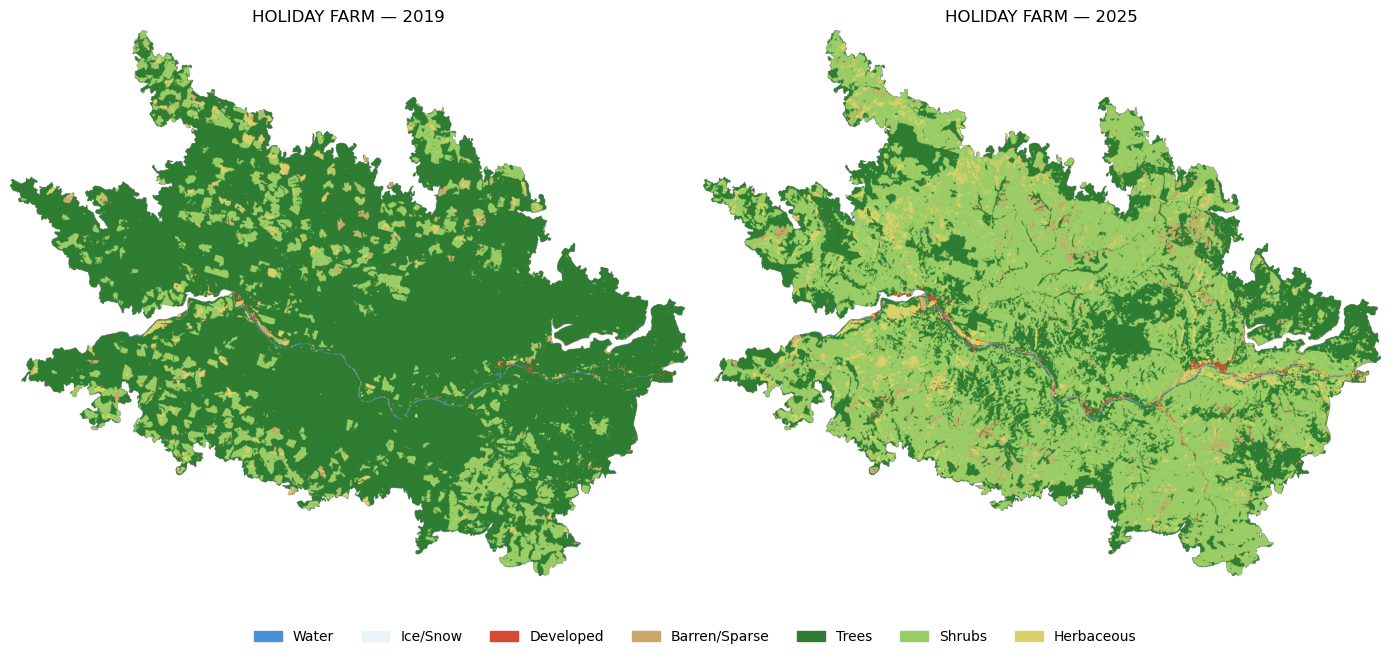

In [11]:
# ── Plot both years side by side with a categorical colormap ────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Point at the mosaics on disk, so this cell runs standalone ──────────────────────────────
# (Step 4 already wrote them; no need to re-download or re-mosaic.)
class_maps = {year: os.path.join(map_dir, f'LULC_Class1_{fire_name.title().replace(" ", "_")}_{year}.tif')
              for year in map_years}
for _y, _p in class_maps.items():
    assert os.path.exists(_p), f'Missing {_p} -- run Step 4 (mosaic) first.'

# class1_dict keys 1-7; NODATA is 255. Colours keyed to the GLanCE Level-1 classes.
class_colors = {1: '#4a90d9', 2: '#e8f4f8', 3: '#d64933', 4: '#c9a66b',
                5: '#2e7d32', 6: '#9acd66', 7: '#d9d26a'}
cmap = ListedColormap([class_colors[k] for k in sorted(class_colors)])
norm = BoundaryNorm([0.5 + k for k in range(0, 8)], cmap.N)

fig, axes = plt.subplots(1, len(map_years), figsize=(7 * len(map_years), 7))
for ax, year in zip(np.atleast_1d(axes), map_years):
    with rasterio.open(class_maps[year]) as src:
        arr = src.read(1).astype(float)
    arr[arr == 255] = np.nan
    ax.imshow(arr, cmap=cmap, norm=norm)
    ax.set_title(f'{fire_name} — {year}')
    ax.axis('off')
handles = [plt.Rectangle((0, 0), 1, 1, color=class_colors[k]) for k in sorted(class1_dict)]
fig.legend(handles, [class1_dict[k] for k in sorted(class1_dict)],
           loc='lower center', ncol=7, frameon=False)
plt.tight_layout()
plt.show()

## Step 6: Validate against MTBS

The pass/fail checks. The headline one: detected Trees to non-Trees area should track the moderate+high-severity area (~63% of the perimeter), not the whole fire.

In [13]:
# ── Change map: pixels that went Trees (5) in 2019 -> non-Trees in 2025 ─────────────────────
with rasterio.open(class_maps[2019]) as s19, rasterio.open(class_maps[2025]) as s25:
    a19, a25 = s19.read(1), s25.read(1)
    pix_m2 = abs(s19.transform.a * s19.transform.e)  # true pixel area (EPSG:5070 -> ~100 m2)
    transform, crs = s19.transform, s19.crs          # kept for the county split below

valid = (a19 != 255) & (a25 != 255)
tree_loss = valid & (a19 == 5) & (a25 != 5)
detected_ha = tree_loss.sum() * pix_m2 / 1e4

detectable_ha = severity_table.loc[['moderate', 'high'], 'hectares'].sum()
high_ha = severity_table.loc['high', 'hectares']
print(f'Detected Trees->non-Trees : {detected_ha:>10,.0f} ha')
print(f'MTBS high severity        : {high_ha:>10,.0f} ha')
print(f'MTBS moderate+high        : {detectable_ha:>10,.0f} ha   <- detection should land near here')
print(f'MTBS full perimeter       : {severity_table.loc["Total","hectares"]:>10,.0f} ha')
print(f'\nRatio detected / (mod+high): {detected_ha / detectable_ha:.2f}   (want roughly 0.7-1.3)')

# ── What did Trees convert to? (should be Barren/Sparse, Herbaceous, or Shrubs) ─────────────
to_classes = a25[tree_loss]
print('\nTrees converted to:')
for c in np.unique(to_classes):
    print(f'  {class1_dict.get(int(c), c):<16s} {(to_classes == c).sum() * pix_m2 / 1e4:>9,.0f} ha')
print('  (Water/Developed here might indicate a pipeline bug, not fire. Or could indicate changes during other times)')

Detected Trees->non-Trees :     36,167 ha
MTBS high severity        :     23,432 ha
MTBS moderate+high        :     44,214 ha   <- detection should land near here
MTBS full perimeter       :     70,298 ha

Ratio detected / (mod+high): 0.82   (want roughly 0.7-1.3)

Trees converted to:
  Water                   16 ha
  Developed              202 ha
  Barren/Sparse        1,899 ha
  Shrubs              31,396 ha
  Herbaceous           2,655 ha
  (Water/Developed here might indicate a pipeline bug, not fire. Or could indicate changes during other times)


## Step 7: Date the change with CCDC

The area test (Step 6) shows *how much* changed; CCDC shows *when*. It runs on Landsat surface reflectance, not AlphaEarth: CCDC fits a seasonal harmonic model to dense intra-annual observations and flags a break when the pattern shifts persistently, and AlphaEarth is only one vector per year.

#### Design

A set number of random points from the classifier's Trees to non-Trees change map (Step 6), plus a stratified addition of Trees to Water and Trees to Developed points, searched for any break across 2019-2025. The random points alone almost never include Water/Developed by chance; those transitions are under 1% of the total change area combined, so they're added on top, clearly tagged (`sample_type`), rather than folded into the "random" draw (which stays a genuine unbiased sample).

#### A finding from the first (50-only) run, worth knowing

Widening the search window from calendar-2020-only to 2019-2025 raised detection from 11/20 (55%) to 49/50 (98%). Most of the newly-recovered breaks land in 2021, not 2020: this matches the Hansen lag pattern from Step 8 (a late-season fire is only fully confirmed in the next year's cloud-free imagery) at the level of individual CCDC fits.

#### What the stratified points add: a real result, not just filled-in boxes

Of 5 sampled Trees to Water points, CCDC found zero breaks (0/5), and 4/5 fall in MTBS `non-mapping`/`outside perimeter` severity (MTBS itself sees no fire impact there either). That convergent evidence, no spectral break and no burn severity, points to these being classifier noise, not real change. Trees to Developed looks different: 4/5 fall in fire-affected severity classes and 4/5 got a CCDC break dated near the fire timeline, suggesting those are largely real (though burn-scar-vs-impervious spectral confusion is a plausible partial explanation for some).

CCDC is expensive: over the whole perimeter it exceeds Earth Engine's interactive memory limit (confirmed the hard way). So the pilot buffers each sampled point to a tiny region and runs CCDC there, one point at a time. A 60-point run (50 random + 5 water + 5 developed) took 307.57 s (5.13 s/point), timed and saved alongside the results.

In [21]:
# ── Run (or load cached) CCDC breaks: 10 random + 10 water + 10 developed points ────────────
import time
import statistics as st
import rasterio.warp
from Change_Detection import prepare_landsat, run_ccdc, fire_window_break, frac_year_to_month

n_points = 10
n_water_target, n_developed_target = 10, 10
search_start_year, search_end_year = 2019, 2026  # searches for ANY break through end of 2025
# CCDC confirmation threshold. run_ccdc's default (6) needs 6 consecutive residual-
# exceeding observations to confirm a break; at noisier post-fire pixels that isn't met
# until the spring after a September fire, lagging the dated break ~6 months. Lowering to
# 4 lets the September discontinuity itself confirm the break. Validated on these 30
# points: median break moved 2021-03-12 -> 2020-09-16 (~8 days off the 2020-09-08
# ignition), on-target (Sep-Oct 2020) count 6 -> 10, at the cost of ~1 extra spurious
# pre-fire break in 30 (the expected commission trade-off; the wall-to-wall step's
# confidence/plausibility gates absorb that, where CCDC only CONFIRMS classifier candidates).
ccdc_min_obs = 4
_tag = (f'{fire_name.title().replace(" ", "_")}_{search_start_year}_{search_end_year}'
       f'_n{n_points}_water{n_water_target}_dev{n_developed_target}')
ccdc_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_breaks_{_tag}.csv')
timing_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_timing_{_tag}.txt')

if rerun_CCDC or not os.path.exists(ccdc_path):
    # General random sample from the CLASSIFIER'S OWN Trees->non-Trees change map (tree_loss,
    # Step 6) -- not restricted to MTBS high severity -- so the check covers any severity and
    # any non-fire cause the classifier may have flagged.
    rng = np.random.default_rng(42)
    change_rows, change_cols = np.where(tree_loss)
    sel = rng.choice(len(change_rows), size=n_points, replace=False)
    sel_rows, sel_cols = change_rows[sel], change_cols[sel]
    sample_type = ['random'] * n_points

    # Stratified addition: explicitly include up to n_water_target Trees->Water and
    # n_developed_target Trees->Developed points, ADDED on top of the random 50 (not drawn
    # from it), so the general sample stays an unbiased draw. These transitions are under 1%
    # of the change area combined, so the random 50 almost never includes them by chance --
    # the first (50-only) run drew zero of either. Falls back to "as many as exist" if fewer
    # than the target are present in the change mask.
    for cls, target, label in [(1, n_water_target, 'stratified_water'),
                               (3, n_developed_target, 'stratified_developed')]:
        cls_rows, cls_cols = np.where(tree_loss & (a25 == cls))
        n_take = min(target, len(cls_rows))
        if n_take < target:
            print(f'Only {len(cls_rows)} Trees->{class1_dict[cls]} pixel(s) exist in the '
                 f'change mask -- sampling all {n_take} (wanted {target}).')
        if n_take > 0:
            take_idx = rng.choice(len(cls_rows), size=n_take, replace=False)
            sel_rows = np.concatenate([sel_rows, cls_rows[take_idx]])
            sel_cols = np.concatenate([sel_cols, cls_cols[take_idx]])
            sample_type += [label] * n_take

    n_total = len(sel_rows)

    # Pixel centers (EPSG:5070, from Step 6) -> lon/lat (EPSG:4326) for Earth Engine.
    xs, ys = rasterio.transform.xy(transform, sel_rows, sel_cols)
    lons, lats = rasterio.warp.transform(crs, 'EPSG:4326', xs, ys)
    to_classes = a25[sel_rows, sel_cols]  # each point's 2025 destination class, read locally

    points_fc = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([lon, lat]), {'pid': i})
        for i, (lon, lat) in enumerate(zip(lons, lats))
    ])

    # MTBS severity at each point, ONE batched call -- a plain int band, not CCDC's expensive
    # array output, so (unlike CCDC itself) all points can be reduced together safely.
    # reduceRegions' output FeatureCollection is NOT guaranteed to preserve input order (an
    # earlier 60-point run's aggregate_array('first') "worked" at n=50 by coincidence, then
    # silently broke at n=60) -- key results by the 'pid' property explicitly instead.
    sev_fc_results = (get_severity_image(fire_year)
                      .reduceRegions(points_fc, ee.Reducer.first(), scale=30)
                      .getInfo()['features'])
    sev_by_pid = {f['properties']['pid']: f['properties'].get('first') for f in sev_fc_results}
    sev_vals = [sev_by_pid.get(i) for i in range(n_total)]

    # Landsat bracketing 2019-2025 (2 yr lead-in; trailing data through today for late-2025
    # breaks, though that tail is thinner than earlier events get, so those dates are less
    # confidently confirmed), then CCDC, then any break inside the search window.
    region = points_fc.geometry().buffer(90)  # ~3-pixel neighbourhoods; keeps CCDC tractable
    landsat = prepare_landsat(region, '2017-01-01', '2026-08-01')
    ccdc = run_ccdc(landsat, min_observations=ccdc_min_obs)
    break_img = fire_window_break(ccdc, search_start_year, search_end_year)

    # Sample one point at a time -- reducing all at once blows the memory limit. Timed, and
    # the elapsed time saved alongside the results (below).
    start_time = time.perf_counter()
    rows = []
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        v = break_img.reduceRegion(ee.Reducer.first(), ee.Geometry.Point([lon, lat]), 30).get('break_year').getInfo()
        sv = sev_vals[i]
        rows.append({
            'lon': lon, 'lat': lat,
            'break_year': v if v and v > 0 else None,
            'severity': sv,
            'severity_name': SEVERITY_NAMES.get(int(sv), 'unknown') if sv is not None else 'outside perimeter',
            'to_class': int(to_classes[i]),
            'to_class_name': class1_dict.get(int(to_classes[i]), str(to_classes[i])),
            'sample_type': sample_type[i],
        })
    elapsed_sec = time.perf_counter() - start_time
    ccdc_breaks = pd.DataFrame(rows)

    os.makedirs(CCDC_OUTPUTS_DIR, exist_ok=True)
    ccdc_breaks.to_csv(ccdc_path, index=False)
    with open(timing_path, 'w') as f:
        f.write(f'{elapsed_sec:.2f} seconds for {n_total} points ({elapsed_sec / n_total:.2f} s/point)\n')
    print(f'Ran CCDC fresh -- saved {len(ccdc_breaks)} points -> {ccdc_path}')
    print(f'CCDC point-loop time: {elapsed_sec:.2f} s ({elapsed_sec / n_total:.2f} s/point) -> {timing_path}')
else:
    ccdc_breaks = pd.read_csv(ccdc_path)
    with open(timing_path) as f:
        print(f'Cached run took: {f.read().strip()}')
    print(f'Loaded cached CCDC breaks ({len(ccdc_breaks)} points) <- {ccdc_path}')
    print('(Set rerun_CCDC = True in the Setup cell to recompute from scratch.)')

breaks = ccdc_breaks['break_year'].dropna().tolist()

print(f'\nCCDC break in [{search_start_year}, {search_end_year}) at '
      f'{len(breaks)}/{len(ccdc_breaks)} sampled points')
if breaks:
    med = st.median(breaks)
    print(f'median break date : {med:.3f} (fractional years)  ->  month {frac_year_to_month(med):.1f}')
    print(f'range             : {min(breaks):.3f} .. {max(breaks):.3f}')
    print(f'fire ignition ref : 2020-09-08 = 2020.688  ->  month 9.3')

print('\nby sample type (breaks found / sampled):')
print(ccdc_breaks.groupby('sample_type')['break_year'].apply(lambda s: f'{s.notna().sum()}/{len(s)}').to_string())
print('\nby severity (breaks found / sampled, random points only):')
print(ccdc_breaks.loc[ccdc_breaks['sample_type'] == 'random']
     .groupby('severity_name')['break_year'].apply(lambda s: f'{s.notna().sum()}/{len(s)}').to_string())

Cached run took: 236.95 seconds for 30 points (7.90 s/point)
Loaded cached CCDC breaks (30 points) <- ./CCDC_Outputs/ccdc_breaks_Holiday_Farm_2019_2026_n10_water10_dev10.csv
(Set rerun_CCDC = True in the Setup cell to recompute from scratch.)

CCDC break in [2019, 2026) at 21/30 sampled points
median break date : 2021.194 (fractional years)  ->  month 3.3
range             : 2020.206 .. 2021.742
fire ignition ref : 2020-09-08 = 2020.688  ->  month 9.3

by sample type (breaks found / sampled):
sample_type
random                  9/10
stratified_developed    9/10
stratified_water        3/10

by severity (breaks found / sampled, random points only):
severity_name
high    8/8
low     1/2


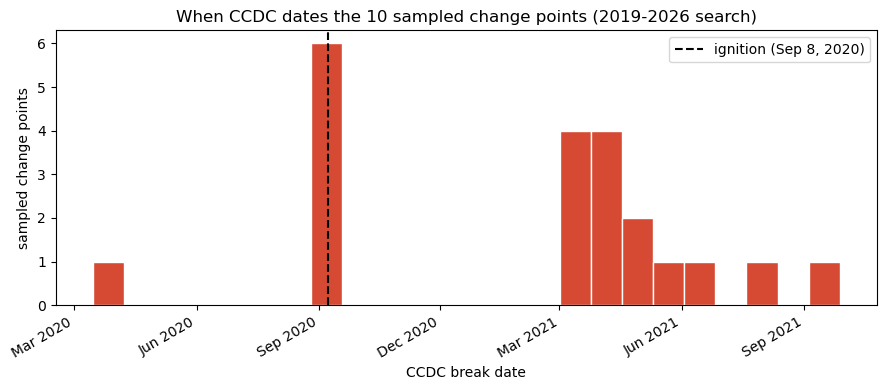

In [22]:
# ── Timeline of break dates (real calendar dates -- breaks now span multiple years) ─────────
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from Change_Detection import frac_year_to_date
rerun_CCDC = True
break_dates = [frac_year_to_date(b) for b in breaks]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(break_dates, bins=24, color='#d64933', edgecolor='white')
ax.axvline(mdates.date2num(dt.date(2020, 9, 8)), color='k', ls='--', label='ignition (Sep 8, 2020)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlabel('CCDC break date')
ax.set_ylabel('sampled change points')
ax.set_title(f'When CCDC dates the {n_points} sampled change points ({search_start_year}-{search_end_year} search)')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

saved -> ./CCDC_Outputs/ccdc_boxplot_Holiday_Farm_2019_2026_n10_water10_dev10.png


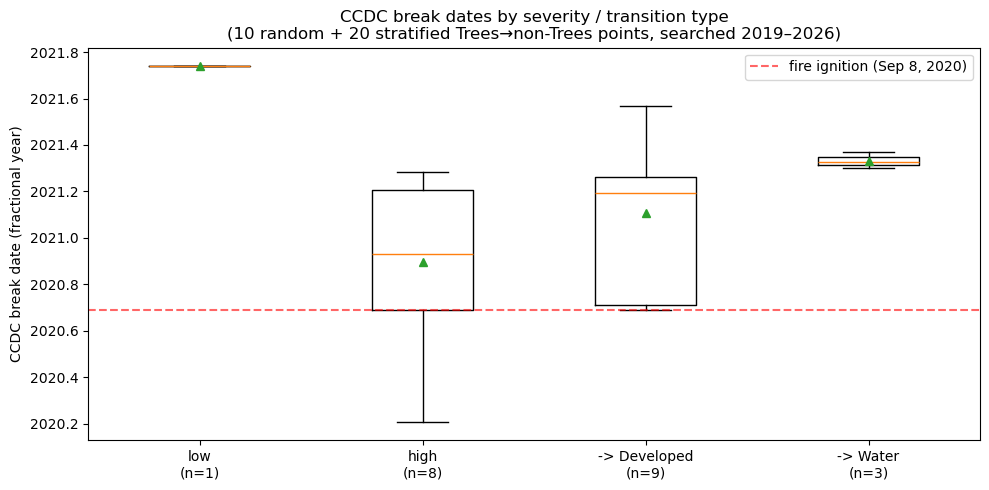


-> Developed: 9/10 points had a CCDC-confirmed break.
-> Water: 3/10 points had a CCDC-confirmed break.


In [23]:
# ── Boxplot: break date by burn severity, and by Trees->Developed / Trees->Water ────────────
import matplotlib.pyplot as plt
# Category = the transition override (Developed/Water) if the point converted to one of those
# rare classes, else its MTBS severity. Developed/Water are always shown, even with 0 points --
# an empty box with "(n=0)" is the honest result for a rare-class random draw, not a bug to hide.
def _category(row):
    if row['to_class_name'] in ('Developed', 'Water'):
        return f"-> {row['to_class_name']}"
    return row['severity_name']

ccdc_breaks['category'] = ccdc_breaks.apply(_category, axis=1)

_severity_order = ['unburned/low', 'low', 'moderate', 'high', 'increased greenness', 'non-mapping']
_present = set(ccdc_breaks['category'])
_order = [c for c in _severity_order if c in _present] + ['-> Developed', '-> Water']

groups, tick_labels = [], []
for cat in _order:
    vals = ccdc_breaks.loc[ccdc_breaks['category'] == cat, 'break_year'].dropna().tolist()
    groups.append(vals)
    tick_labels.append(f'{cat}\n(n={len(vals)})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(groups, tick_labels=tick_labels, showmeans=True)
ax.axhline(2020.688, color='r', ls='--', alpha=0.6, label='fire ignition (Sep 8, 2020)')
ax.set_ylabel('CCDC break date (fractional year)')
ax.set_title(f'CCDC break dates by severity / transition type\n'
            f'({n_points} random + {len(ccdc_breaks) - n_points} stratified Trees\u2192non-Trees points, '
            f'searched {search_start_year}\u2013{search_end_year})')
ax.legend()
plt.tight_layout()

_boxplot_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_boxplot_{_tag}.png')
plt.savefig(_boxplot_path, dpi=150, bbox_inches='tight')
print(f'saved -> {_boxplot_path}')
plt.show()

print()
for _cat in ['-> Developed', '-> Water']:
    _sub = ccdc_breaks[ccdc_breaks['category'] == _cat]
    _n_sampled, _n_dated = len(_sub), _sub['break_year'].notna().sum()
    if _n_sampled == 0:
        print(f'{_cat}: no such points existed in the change mask.')
    elif _n_dated == 0:
        print(f'{_cat}: {_n_sampled} points sampled, CCDC found a break at NONE of them -- '
             f'check their MTBS severity above; no break + no fire severity usually means '
             f'classifier noise, not real change.')
    else:
        print(f'{_cat}: {_n_dated}/{_n_sampled} points had a CCDC-confirmed break.')

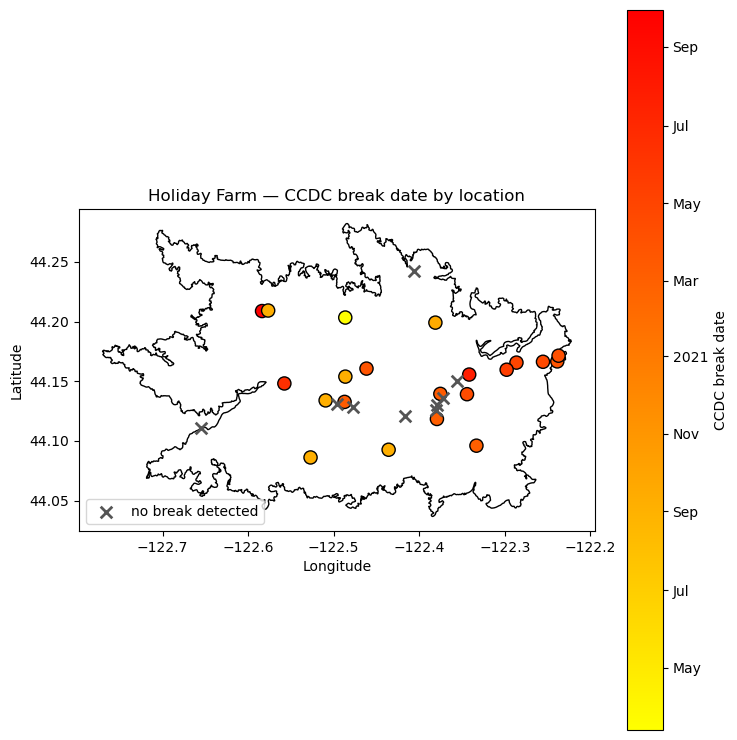

In [24]:
# ── Map: CCDC break date by location (color = when each point burned) ───────────────────────
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from shapely.geometry import shape
from Change_Detection import frac_year_to_date

ccdc_breaks['break_date'] = ccdc_breaks['break_year'].apply(
    lambda v: frac_year_to_date(v) if pd.notna(v) else pd.NaT)
has_break = ccdc_breaks['break_date'].notna()

fire_shape = gpd.GeoDataFrame(geometry=[shape(fire_geometry.getInfo())], crs='EPSG:4326')

# Autoscale color to the OBSERVED date range, not the full year -- with breaks clustered in a
# ~3-week window, a Jan-Dec scale would make every point look nearly identical.
dates_num = mdates.date2num(ccdc_breaks.loc[has_break, 'break_date'])
vmin, vmax = dates_num.min() - 2, dates_num.max() + 2

fig, ax = plt.subplots(figsize=(7.5, 7.5))
fire_shape.boundary.plot(ax=ax, color='black', linewidth=1)
sc = ax.scatter(ccdc_breaks.loc[has_break, 'lon'], ccdc_breaks.loc[has_break, 'lat'],
                c=dates_num, cmap='autumn_r', s=90, edgecolor='black', vmin=vmin, vmax=vmax, zorder=3)
ax.scatter(ccdc_breaks.loc[~has_break, 'lon'], ccdc_breaks.loc[~has_break, 'lat'],
          marker='x', color='#555555', s=70, linewidths=2, label='no break detected', zorder=3)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('CCDC break date')
cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
cbar.ax.yaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_title(f'{fire_name.title()} — CCDC break date by location')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

### NDVI / NBR time series at every sampled point

One diagnostic plot per point: NDVI and NBR (burn index) over 2017-2026, with the fire ignition date and (if found) the CCDC break date both marked. This is what actually justifies trusting or distrusting a CCDC date, rather than taking the fitted break on faith.

#### A concrete example worth opening directly

The points CCDC dated to *before* the fire (search the printed list below for `break_year < 2020`) show a genuine, permanent step-down in both indices around their break date, not a crash at the fire's September 2020 ignition. That is independent visual confirmation those are real, separate (likely harvest) disturbances, not a CCDC dating artifact. Compare against a random high-severity point, where both indices instead crash sharply right at the fire date and recover slowly over the following years (the textbook post-fire signature), and against a stratified Water point with no CCDC break, where neither index shows any discontinuity anywhere in the full record, corroborating the classifier-noise finding above with an independent signal.

Saved to `CCDC_Outputs/timeseries_{tag}/`, one PNG per point (`pt{{index}}_{{sample_type}}_{{break|nobreak}}.png`); a handful are shown inline below.

In [27]:
# ── NDVI / NBR time series for every sampled point, saved as one PDF, break date marked ─────
import pickle
import time as _time
from matplotlib.backends.backend_pdf import PdfPages
from Change_Detection import (prepare_landsat, add_indices, point_index_timeseries,
                              plot_index_timeseries, pick_example_points)

ts_pdf_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_timeseries_{_tag}.pdf')
ts_timing_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_timeseries_timing_{_tag}.txt')
ts_examples_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_timeseries_examples_{_tag}.pkl')

if rerun_CCDC or not os.path.exists(ts_pdf_path):
    # Standalone (works whether Step 7 just ran fresh or loaded from cache): rebuilds the
    # Landsat collection from ccdc_breaks' own lon/lat rather than depending on the Run/load
    # cell's in-session `landsat`/`region`.
    _region = ee.Geometry.MultiPoint(ccdc_breaks[['lon', 'lat']].values.tolist()).buffer(90)
    _idx_collection = prepare_landsat(_region, '2017-01-01', '2026-08-01').map(add_indices)
    _example_indices = {i for i, _ in pick_example_points(ccdc_breaks).values()}

    print(f'Extracting NDVI/NBR time series for {len(ccdc_breaks)} points '
         f'(~{7 * len(ccdc_breaks) / 60:.0f}s expected)...')
    _start = _time.perf_counter()
    _example_ts = {}
    with PdfPages(ts_pdf_path) as _pdf:
        for i, row in ccdc_breaks.iterrows():
            ts = point_index_timeseries(_idx_collection, row['lon'], row['lat'])

            fig, ax = plt.subplots(figsize=(9, 4))
            plot_index_timeseries(ax, i, row, ts)
            plt.tight_layout()
            _pdf.savefig(fig)
            plt.close(fig)

            if i in _example_indices:
                _example_ts[i] = ts  # kept for the standalone preview cell below
    _elapsed = _time.perf_counter() - _start

    with open(ts_timing_path, 'w') as f:
        f.write(f'{_elapsed:.2f} seconds for {len(ccdc_breaks)} points ({_elapsed / len(ccdc_breaks):.2f} s/point)\n')
    with open(ts_examples_path, 'wb') as f:
        pickle.dump(_example_ts, f)
    print(f'Saved {len(ccdc_breaks)} time series pages -> {ts_pdf_path}')
    print(f'Time-series extraction time: {_elapsed:.2f} s ({_elapsed / len(ccdc_breaks):.2f} s/point) -> {ts_timing_path}')
else:
    with open(ts_timing_path) as f:
        print(f'Cached run took: {f.read().strip()}')
    print(f'Loaded cached time-series PDF <- {ts_pdf_path}')
    print('(Set rerun_CCDC = True in the Setup cell to recompute from scratch.)')

Extracting NDVI/NBR time series for 30 points (~4s expected)...
Saved 30 time series pages -> ./CCDC_Outputs/ccdc_timeseries_Holiday_Farm_2019_2026_n10_water10_dev10.pdf
Time-series extraction time: 192.32 s (6.41 s/point) -> ./CCDC_Outputs/ccdc_timeseries_timing_Holiday_Farm_2019_2026_n10_water10_dev10.txt


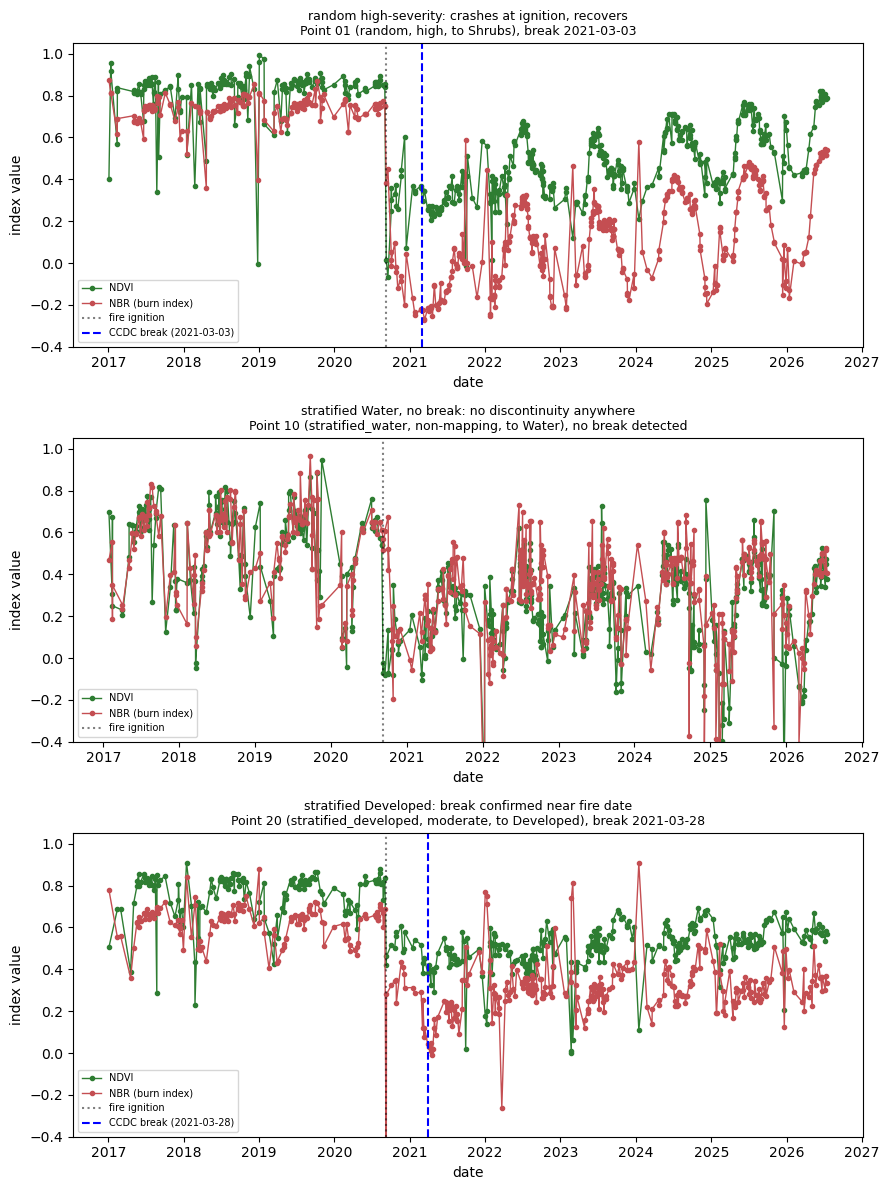

In [28]:
# ── Preview a few representative examples inline, read from disk (no GEE call needed) ───────
# Fully standalone: reads the example points' time series back from the small pickle saved
# alongside the PDF above, so this cell runs with rerun_CCDC = False even in a fresh kernel
# that never ran the extraction cell this session -- no Earth Engine query either way.
import pickle
from Change_Detection import plot_index_timeseries, pick_example_points

ts_examples_path = os.path.join(CCDC_OUTPUTS_DIR, f'ccdc_timeseries_examples_{_tag}.pkl')

if os.path.exists(ts_examples_path):
    with open(ts_examples_path, 'rb') as f:
        _example_ts = pickle.load(f)
    _examples = {label: (i, row, _example_ts[i])
                for label, (i, row) in pick_example_points(ccdc_breaks).items()
                if i in _example_ts}

    if _examples:
        fig, axes = plt.subplots(len(_examples), 1, figsize=(9, 4 * len(_examples)))
        for ax, (label, (i, row, ts)) in zip(np.atleast_1d(axes), _examples.items()):
            plot_index_timeseries(ax, i, row, ts, extra_label=label)
        plt.tight_layout()
        plt.show()
    else:
        print('No matching example points found for the inline preview.')
else:
    print(f'No cached example time series found at {ts_examples_path}.')
    print('Run the extraction cell above first (with rerun_CCDC = True if the PDF is stale).')

## Step 8: Cross-check the date against Hansen

CCDC (Step 7) is our own dating; Hansen Global Forest Change is an independent, pre-computed forest-loss product (`UMD/hansen/global_forest_change_2025_v1_13`, `lossyear` band, ~30 m annual). If both say 2020, the date is corroborated by a source with entirely different methods and inputs.

Hansen is annual (coarser than CCDC's sub-annual break), and it has a known quirk: late-season fires spill partly into the *next* year, because the loss is only confirmed in the following year's cloud-free imagery. So a September-2020 burn shows up as mostly 2020 with a chunk of 2021; both are the fire.

In [29]:
# ── Hansen loss-year distribution within the MTBS high-severity zone ────────────────────────
from Change_Detection import loss_year_table

high_sev = get_severity_image(fire_year).eq(4).selfMask()
hansen_tbl = loss_year_table(fire_geometry, mask=high_sev)

print('Hansen forest-loss year within the high-severity zone:')
display(hansen_tbl.sort_values('hectares', ascending=False).head(6).round(1))

fire_frac = hansen_tbl.reindex([fire_year, fire_year + 1])['fraction'].sum()
print(f'Any loss detected     : {hansen_tbl["fraction"].sum() * 100:5.1f}% of the high-severity zone')
print(f'Dated {fire_year}            : {hansen_tbl["fraction"].get(fire_year, 0) * 100:5.1f}%')
print(f'Dated {fire_year} or {fire_year + 1}       : {fire_frac * 100:5.1f}%   (Hansen lags late-season fires ~1 yr)')
print(f'\nAgreement: CCDC (Sep 8, {fire_year}), Hansen ({fire_year}/{fire_year + 1}), and MTBS '
      f'(ignited {fire_year}-09-08) all place the change in {fire_year}.')

Hansen forest-loss year within the high-severity zone:


,hectares,fraction
year,,
2020,16234.1,0.7
2021,5860.8,0.3
2019,181.7,0.0
2002,179.3,0.0
2003,171.4,0.0
2001,167.8,0.0


Any loss detected     : 100.0% of the high-severity zone
Dated 2020            :  69.4%
Dated 2020 or 2021       :  94.4%   (Hansen lags late-season fires ~1 yr)

Agreement: CCDC (Sep 8, 2020), Hansen (2020/2021), and MTBS (ignited 2020-09-08) all place the change in 2020.


## Step 9: Activity data (area of change by county)

The first step of carbon accounting is activity data: *how much* forest was lost, per reporting domain (county). This attributes the Trees to non-Trees change to the counties the fire spans by rasterizing the county polygons onto the change grid, so each pixel lands in exactly one county and the split reconciles with the total. (The remaining carbon piece, multiplying by a per-county FIA emission factor, is Step 10, still to wire up.)

In [30]:
# ── Attribute the Trees->non-Trees change to counties ───────────────────────────────────────
from Geo_Utils import get_counties
from Carbon_Accounting import area_by_polygons

# The Holiday Farm Fire spans Lane and Linn (both Oregon). For the full WA+OR run, drop the
# `names` filter and key on GEOID -- county NAMEs collide across the two states.
PILOT_COUNTY_NAMES = ['Lane', 'Linn']
counties = get_counties(names=PILOT_COUNTY_NAMES)
county_area, outside_ha = area_by_polygons(tree_loss, transform, crs, counties, label_col='NAME')

print('Trees -> non-Trees area by county:')
display(county_area.round(0))
print(f'outside Lane/Linn  : {outside_ha:>8,.0f} ha   (should be ~0 -> fire fully inside these two)')
print(f'reconcile          : {county_area["hectares"].sum() + outside_ha:>8,.0f} ha   '
      f'vs {detected_ha:,.0f} ha detected')

Trees -> non-Trees area by county:


,hectares,fraction
NAME,,
Lane,34203.0,1.0
Linn,1964.0,0.0


outside Lane/Linn  :        0 ha   (should be ~0 -> fire fully inside these two)
reconcile          :   36,167 ha   vs 36,167 ha detected


## Step 10: Aboveground carbon lost (Activity Data × Emission Factor)

Carbon lost = area of forest lost (Step 9) × carbon density (Mg C/ha). This is the standard IPCC/VCS accounting form, and it's the *reason* the county split matters: carbon is reported as county totals, not a per-pixel map.

#### Emission factors come from FIA, not from a model

This is the decided approach: FIA gives design-based aboveground biomass per county with a sampling error (Tier 2, free), and its ~1-mile plot-coordinate fuzzing is irrelevant at county scale. Convert biomass to carbon with the IPCC 0.47 fraction (0.50 shown as a conifer sensitivity).

#### FIA is a manual pull

It is *not* in Earth Engine and its API is not reachable here, so the `FIA_BIOMASS_EF` values below are placeholders you must replace with a real [FIA EVALIDator](https://apps.fs.usda.gov/fiadb-api/evalidator) query (aboveground biomass, tons/acre, by county, for the Lane/Linn evaluation; use `TONS_PER_ACRE_TO_MG_PER_HA` to convert). Until then the carbon total below is illustrative only.

#### Verra framing: read before quoting any number

The AD × EF structure and Tier-2 FIA factors are conventional. But two gaps make this jurisdictional-style, not crediting-grade: (1) the area is map-counted, biased high and with no confidence interval (Olofsson sample-based estimation is the accepted fix); so (2) the ± below reflects FIA emission-factor uncertainty only and understates the total. No project-specific field plots, no conservativeness deductions, no VVB review. Report it as an estimate with that caveat, never as a creditable figure.

In [32]:
# ── Emission factors: FIA aboveground biomass (Mg/ha) per county ────────────────────────────
from Carbon_Accounting import carbon_from_area, convert_tons_acre_to_mg_ha

FIA_EF_df = pd.read_csv(f'{FIA_DATA_DIR}/FIADB_API_Estimates_183129161.csv')

FIA_BIOMASS_EF = {
}
for county in PILOT_COUNTY_NAMES:
    #print(county)
    county_EF_df = FIA_EF_df.loc[FIA_EF_df['COUNTY_CODE_AND_NAME'].str.contains(county,na=False),]
    county_EF = county_EF_df.loc[county_EF_df['OWNERSHIP_GROUP'] == "Total",]
    county_AGB = convert_tons_acre_to_mg_ha(county_EF['RATIO_ESTIMATE'].iloc[0])
    county_AGB_SE = convert_tons_acre_to_mg_ha(county_EF['RATIO_SE'].iloc[0])
    FIA_BIOMASS_EF[county] = (county_AGB,county_AGB_SE)

# ── AD x EF, with the IPCC 0.47 carbon fraction and a 0.50 conifer sensitivity ──────────────
carbon = carbon_from_area(county_area, FIA_BIOMASS_EF, carbon_fraction=0.47)
carbon_hi = carbon_from_area(county_area, FIA_BIOMASS_EF, carbon_fraction=0.50)

print(f'Aboveground carbon lost, Holiday Farm Fire (Lane + Linn)')
display(carbon.round(0))

tot, se = carbon.loc['TOTAL', 'carbon_mg'], carbon.loc['TOTAL', 'carbon_se_mg']
print(f'\nTotal (x0.47): {tot:>14,.0f} +/- {se:,.0f} Mg C   (EF uncertainty only)')
print(f'Total (x0.50): {carbon_hi.loc["TOTAL","carbon_mg"]:>14,.0f} Mg C   (conifer sensitivity)')
print(f'Implied EF   : {tot / county_area["hectares"].sum():.0f} Mg C/ha   '
      f'(PNW conifer sanity range ~100-250)')


Aboveground carbon lost, Holiday Farm Fire (Lane + Linn)


,hectares,agb_mg_ha,agb_se_mg_ha,carbon_mg,carbon_se_mg
NAME,,,,,
Lane,34203.0,157.0,5.0,2525783.0,73944.0
Linn,1964.0,120.0,6.0,111082.0,5815.0
TOTAL,36167.0,NaN,NaN,2636866.0,74172.0



Total (x0.47):      2,636,866 +/- 74,172 Mg C   (EF uncertainty only)
Total (x0.50):      2,805,176 Mg C   (conifer sensitivity)
Implied EF   : 73 Mg C/ha   (PNW conifer sanity range ~100-250)
